- 이상치 제거 : 아이솔레이션
- 파생변수: 콜레스테롤/HDL, LDL/HDL, 중성지방/HDL, 공복혈당/BMI
- 제거한 변수: ID (파생변수 사용된 컬럼도 그대로 둠)
- 정규화X
- cv = 10

### 라이브러리

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import numpy as np

# train 데이터 정리하기

In [2]:
df = pd.read_csv('train.csv')

## 데이터 탐색

### 결측치 확인 (Nan, 일부 컬럼 대상 0)

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        7000 non-null   object 
 1   나이        7000 non-null   int64  
 2   키(cm)     7000 non-null   int64  
 3   몸무게(kg)   7000 non-null   int64  
 4   BMI       7000 non-null   float64
 5   시력        7000 non-null   float64
 6   충치        7000 non-null   int64  
 7   공복 혈당     7000 non-null   int64  
 8   혈압        7000 non-null   int64  
 9   중성 지방     7000 non-null   int64  
 10  혈청 크레아티닌  7000 non-null   float64
 11  콜레스테롤     7000 non-null   int64  
 12  고밀도지단백    7000 non-null   int64  
 13  저밀도지단백    7000 non-null   int64  
 14  헤모글로빈     7000 non-null   float64
 15  요 단백      7000 non-null   int64  
 16  간 효소율     7000 non-null   float64
 17  label     7000 non-null   int64  
dtypes: float64(5), int64(12), object(1)
memory usage: 984.5+ KB


Nan 없음 확인

In [248]:
null_cols = ['나이', '키(cm)', '몸무게(kg)', 'BMI', '시력', '공복 혈당', '혈압', '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '간 효소율']
(df[null_cols]==0).sum()

나이          0
키(cm)       0
몸무게(kg)     0
BMI         0
시력          0
공복 혈당       0
혈압          0
중성 지방       0
혈청 크레아티닌    0
콜레스테롤       0
고밀도지단백      0
저밀도지단백      0
헤모글로빈       0
간 효소율       0
dtype: int64

0이 나오면 결측치로 볼 수 있는 컬럼에서 값==0 없음 확인

### 데이터 분포 확인

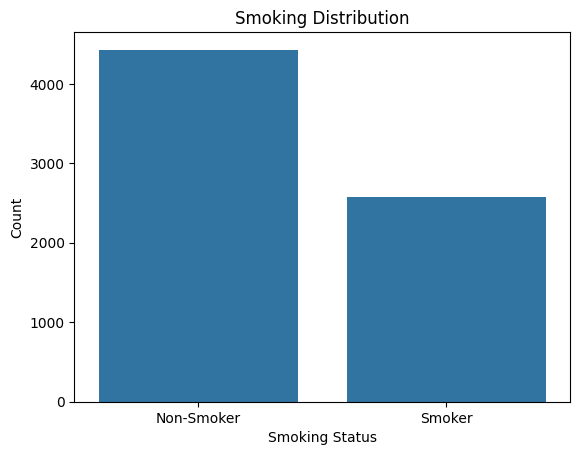

In [249]:
sns.countplot(x='label', data=df)

plt.title('Smoking Distribution')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Non-Smoker', 'Smoker'])
plt.show()

데이터 분포상 비흡연자:흡연자 비율은 약 2:1 정도

- 전체 데이터 분포 확인

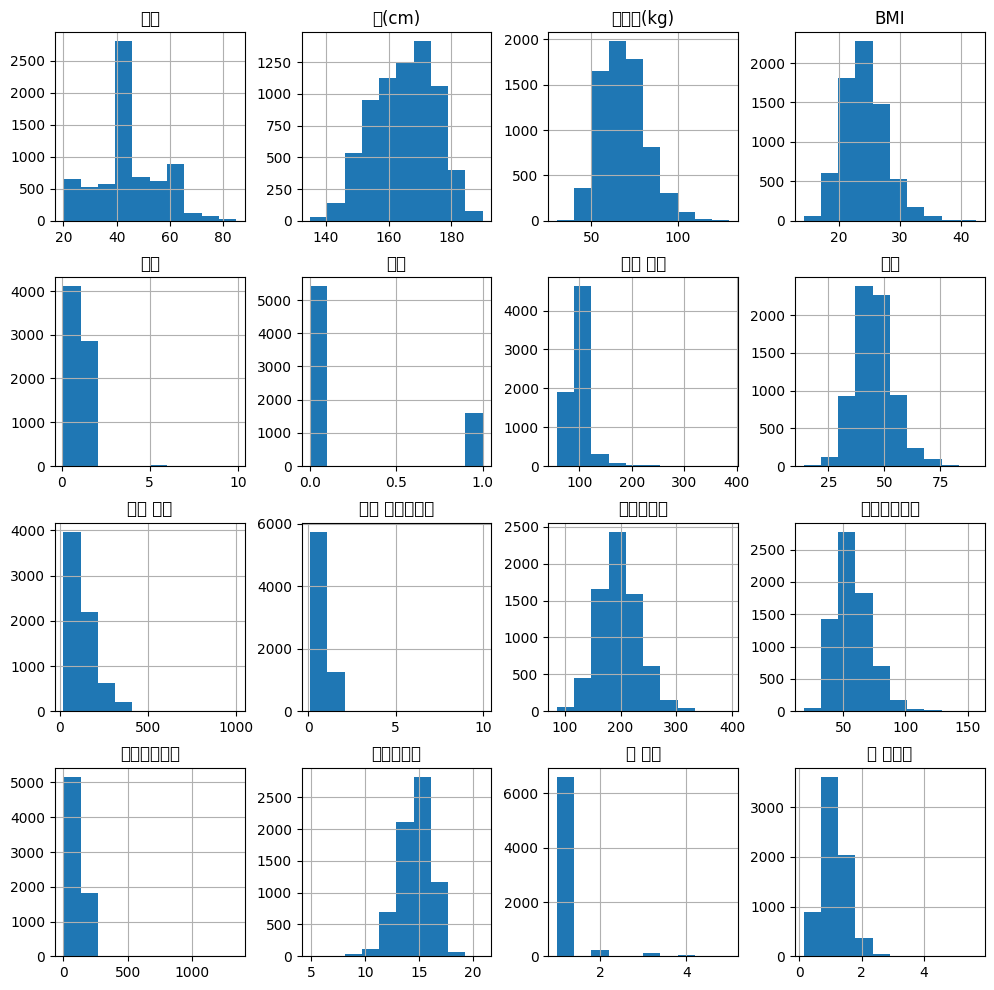

In [250]:
exp_target = df.drop('label', axis=1)
exp_target.hist(figsize=(12,12))
plt.show()

- 연령별 흡연율 확인

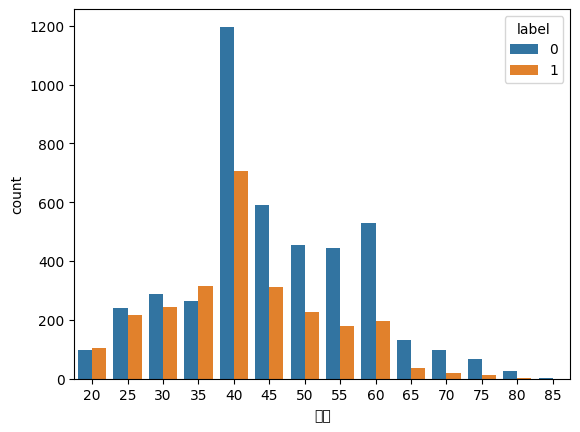

In [251]:
sns.countplot(x='나이', hue='label', data=df)
plt.show()

- 상관관계 확인

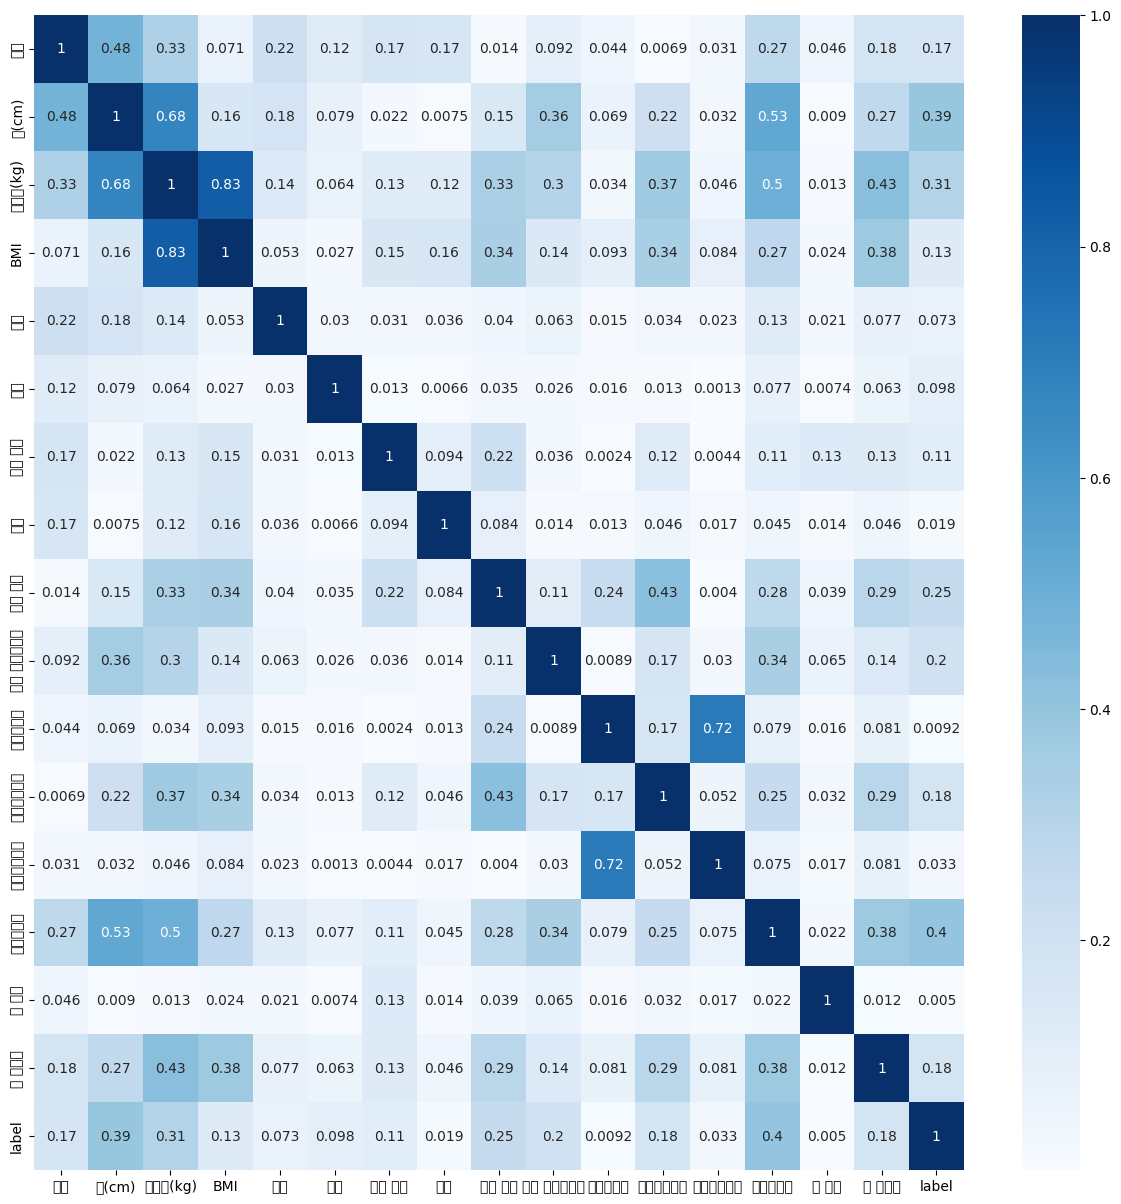

In [252]:
plt.figure(figsize=(15,15), dpi=100)
sns.heatmap(abs(df.drop('ID', axis=1).corr()), annot=True, cmap='Blues')
plt.show()

feature간 상관관계 0.3 이상인 것들

In [253]:
((abs(df.drop(['ID','label'], axis=1).corr())>0.5).sum())>=2

나이          False
키(cm)        True
몸무게(kg)      True
BMI          True
시력          False
충치          False
공복 혈당       False
혈압          False
중성 지방       False
혈청 크레아티닌    False
콜레스테롤        True
고밀도지단백      False
저밀도지단백       True
헤모글로빈        True
요 단백        False
간 효소율       False
dtype: bool

In [254]:
(abs(df.drop(['ID','label', '시력', '충치', '공복 혈당', '혈압','요 단백'], axis=1).corr())>0.6).sum()

나이          1
키(cm)       2
몸무게(kg)     3
BMI         2
중성 지방       1
혈청 크레아티닌    1
콜레스테롤       2
고밀도지단백      1
저밀도지단백      2
헤모글로빈       1
간 효소율       1
dtype: int64

-> feature간 상관관계 높은 변수들

## 이상치 범위 선택 : 표준편차, IQR, 아이솔레이션 모델링

In [133]:
# 반복문으로 컬럼 이상치 없애면서, 컬럼1에서 이상치 제거한 데이터 기반으로 컬럼2의 이상치를 추적. 이를 반복하다보니 데이터 손실이 가중되었음
# 표준편차, IQR 버전: 각 칼럼의 이상치 행를 인덱스로 리스트에 모아 중복값을 없애어, 각 컬럼의 전체 데이터를 대상으로 한 이상치를 모음.
# Isolation 버전 : 이상치인 행들을 anomaly 컬럼에서 -1(이상치), 또는 1로 생성

### 이상치 (표준편차 버전)

In [126]:
cols = ['BMI', '시력', '공복 혈당', '혈압', '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '간 효소율']

idxs = []

df_outlier = df.copy()

for col in cols:
    mean = df[col].mean()
    std = df[col].std()
    
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    df_outlier = df_outlier[(df[col] <= lower) | (df[col] >= upper)]
    idxs.append(df_outlier.index.values)

In [129]:
out_l = np.concatenate(idxs)
len(out_l)

48

In [ ]:
df = df.drop(index=out_l)

### 이상치 (IQR 버전)

In [399]:
cols = ['BMI', '시력', '공복 혈당', '혈압', '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '간 효소율']

idxs = []

df_outlier = df.copy()

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_outlier = df_outlier[(df[col] <= lower) | (df[col] >= upper)]
    idxs.append(df_outlier.index.values)

out_l = np.concatenate(idxs)
len(out_l)

235

In [256]:
df = df.drop(index=out_l)

### winsorizing

In [506]:
def winsorize_quantile(df, cols=None, lower_q=0.01, upper_q=0.99):
    """
    Quantile 기반 winsorizing
    lower_q~upper_q 사이 값만 유지하고 바깥은 컷팅
    """
    if cols is None:
        cols = ['혈압', '혈청 크레아티닌', '고밀도지단백', '저밀도지단백']

    df_new = df.copy()
    bounds = {}

    for col in cols:
        low = df[col].quantile(lower_q)
        high = df[col].quantile(upper_q)

        # 저장
        bounds[col] = (low, high)

        # 윈저라이징
        df_new[col] = np.clip(df[col], low, high)

    return df_new, bounds

# 사용 예시
df_winsor, cut_bounds = winsorize_quantile(df, lower_q=0.01, upper_q=0.99)

print(cut_bounds)

{'혈압': (np.float64(28.0), np.float64(70.0)), '혈청 크레아티닌': (np.float64(0.5), np.float64(1.3)), '고밀도지단백': (np.float64(32.0), np.float64(100.0)), '저밀도지단백': (np.float64(45.0), np.float64(203.0))}


In [507]:
df = df_winsor

### Isolation Forest V

In [3]:
from sklearn.ensemble import IsolationForest

In [4]:
cols = ['BMI', '시력', '공복 혈당', '혈압', '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '간 효소율']

X = df[cols]

iso = IsolationForest(
    n_estimators=200,
    contamination='auto',   # 전체에서 몇%를 이상치라고 할지
    random_state=42,
    n_jobs=-1
)

iso.fit(X)

df['anomaly'] = iso.predict(X)
out_l = df[df['anomaly']==-1]
print(len(out_l))

df = df[df['anomaly']==1]

318


In [651]:
df = df.drop('anomaly', axis=1)

## feature engineering

### BMI (binning, encoding)

In [54]:
bins = [0, 18.5, 23, 25, 30, 100]
labels = ['저체중', '정상', '과체중', '비만', '고도비만']

df['BMI구간'] = pd.cut(df['BMI'], bins=bins, labels=labels, right=False)


In [57]:
# BMI Ordinal Mapping
bmi_map = {
    "저체중": 1,
    "정상": 2,
    "과체중": 3,
    "비만": 4,
    "고도비만": 5
}

# 적용
df["BMI_encoded"] = df["BMI구간"].map(bmi_map).astype(int)

### 나이 (binning, encoding)

In [371]:
df['age_encoded'] = np.where(df['나이']<85, df['나이']//5, 17)

In [251]:
df['age_encoded'].unique()

array([ 7, 12,  8, 11, 10,  9, 15,  4,  5,  6, 14, 13, 16, 17])

### 파생변수 (interaction)1 : 나이, BMI 회귀 제거(residualization)-> 각종 생체 지표
- 각 건강지표를 나이, BMI로 예측한 후, 그 예측에서 벗어난 정도(잔차)가 '나이와 BMI에 영향을 받지 않는 건강상태'라고 봄.
- 나이 및 BMI 효과를 제거하고, 남은 변화를 흡연 또는 개인 생활습관에 의한 변화로 간주

- 잔차화

In [235]:
import statsmodels.api as sm

In [612]:
def residualize(df, target_col, control_cols):
    X = df[control_cols]
    X = sm.add_constant(X)
    y = df[target_col]

    model = sm.OLS(y, X).fit()
    resid = model.resid
    return resid

control_vars = ["나이", "BMI"]

df["BP_resid"] = residualize(df, "혈압", control_vars)
df["TG_resid"] = residualize(df, "중성 지방", control_vars)
df["Chol_resid"] = residualize(df, "콜레스테롤", control_vars)
df["HDL_resid"] = residualize(df, "고밀도지단백", control_vars)
df["LDL_resid"] = residualize(df, "저밀도지단백", control_vars)
df["ALT_resid"] = residualize(df, "간 효소율", control_vars)
df["Glu_resid"] = residualize(df, "공복 혈당", control_vars)
df["Hemo_resid"] = residualize(df, "헤모글로빈", control_vars)
df["Crea_resid"] = residualize(df, "혈청 크레아티닌", control_vars)

- 잔차화 후 파생변수 생성

In [373]:
# 1) 설정값: 너무 작은 분모는 이 값으로 올려줌
min_abs = 1e-2   # 최소 절댓값 (0.01 정도)
clip_val = 50    # 최종 비율은 [-50, 50] 사이로 잘라줌

# 2) HDL_resid를 안전한 분모로 변환
hdl = df["HDL_resid"].copy()

# (1) 절댓값이 너무 작은 경우 찾기
small = hdl.abs() < min_abs

# (2) 너무 작은 값들은 부호는 유지하면서 절댓값을 min_abs로 맞춰줌
#     - 양수면 +0.01
#     - 음수면 -0.01
hdl.loc[small & (hdl >= 0)] = min_abs
hdl.loc[small & (hdl < 0)]  = -min_abs

# (3) 혹시 0이 남아 있으면 강제로 min_abs로 변경
hdl.replace(0, min_abs, inplace=True)

# 3) TG_resid / HDL_resid (안전 버전)
df["tg_hdl_ratio_resid"] = (df["TG_resid"] / hdl).clip(-clip_val, clip_val)

# 4) LDL_resid / HDL_resid (안전 버전)
df["ldl_hdl_ratio_resid"] = (df["LDL_resid"] / hdl).clip(-clip_val, clip_val)

### 파생변수2 : Chol/HDL, LDL/HDL, TG/HDL, Glu/BMI V

In [5]:
df['Chol_HDL'] = df['콜레스테롤']/df['고밀도지단백']
df['LDL_HDL'] = df['저밀도지단백']/df['고밀도지단백']
df['TG_HDL'] = df['중성 지방']/df['고밀도지단백']
df['Glu_BMI'] = df['공복 혈당']/df['BMI']

### VIP 다중공선성 제거

In [77]:
ec_df = df.drop(['키(cm)', '몸무게(kg)', 'BMI구간', '나이구간', 'ID', '나이', 'BMI', 'anomaly', '시력'], axis=1)

- VIF

In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [32]:
def calculate_vif(df):
    vif_df = pd.DataFrame()
    vif_df["feature"] = df.columns
    vif_df["VIF"] = [variance_inflation_factor(df.values, i)
                     for i in range(df.shape[1])]
    return vif_df

X = ec_df.drop('label', axis=1)

threshold = 15
removed_features = []

while True:
    vif_df = calculate_vif(X)

    max_vif = vif_df["VIF"].max()

    if max_vif < threshold:
        break

    drop_feature = vif_df.loc[vif_df["VIF"].idxmax(), "feature"]

    # 🔥 안전장치 추가: X에 존재할 때만 제거
    if drop_feature not in X.columns:
        print(f"⚠️ Warning: {drop_feature} is not in X, skip.")
        removed_features.append(drop_feature)
        continue

    print(f"Remove {drop_feature} (VIF={max_vif:.2f})")
    removed_features.append(drop_feature)

    X = X.drop(columns=[drop_feature])

print("\n=== 최종 남은 Feature ===")
print(list(X.columns))

print("\n=== 제거된 Feature ===")
print(removed_features)

Remove 콜레스테롤 (VIF=114.15)
Remove 헤모글로빈 (VIF=82.14)
Remove 공복 혈당 (VIF=37.46)
Remove 혈압 (VIF=26.09)
Remove 고밀도지단백 (VIF=15.39)

=== 최종 남은 Feature ===
['충치', '중성 지방', '혈청 크레아티닌', '저밀도지단백', '요 단백', '간 효소율', 'BMI_encoded', 'age_encoded']

=== 제거된 Feature ===
['콜레스테롤', '헤모글로빈', '공복 혈당', '혈압', '고밀도지단백']


### feature selection
기본 제거 : 'ID' V

In [6]:
p_df = df.drop(['ID'], axis=1)

In [7]:
p_df

,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,...,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,anomaly,Chol_HDL,LDL_HDL,TG_HDL,Glu_BMI
0,35,170,70,24.22,1.10,1,98,40,80,1.3,...,120,15.9,1,1.53,1,1,2.813333,1.600000,1.066667,4.046243
2,60,170,50,17.30,0.75,0,96,40,61,0.8,...,89,15.3,1,1.04,0,1,3.348837,2.069767,1.418605,5.549133
3,40,150,45,20.00,0.50,0,92,40,46,0.7,...,110,13.4,1,1.18,0,1,2.696970,1.666667,0.696970,4.600000
4,55,155,65,27.06,1.00,0,87,42,95,0.9,...,151,13.8,1,1.32,0,1,3.741935,2.435484,1.532258,3.215078
5,50,160,55,21.48,1.05,0,79,53,112,0.7,...,128,13.6,1,0.95,0,1,3.253731,1.910448,1.671642,3.677840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25,170,65,22.49,1.50,0,87,45,141,1.2,...,112,14.9,1,1.50,0,1,4.181818,2.545455,3.204545,3.868386
6996,60,165,65,23.88,0.90,0,87,45,82,0.9,...,103,14.3,1,1.47,1,1,2.875000,1.609375,1.281250,3.643216
6997,40,180,100,30.86,1.20,0,97,44,87,0.9,...,107,15.6,1,1.00,0,1,3.296296,1.981481,1.611111,3.143227
6998,60,150,55,24.44,0.60,0,89,57,161,0.6,...,76,14.4,1,1.00,0,1,3.204082,1.551020,3.285714,3.641571


In [613]:
p_df = df.drop([
    'ID', # 상관없는 것들
    'BMI',
    '혈압', '콜레스테롤', '고밀도지단백', '저밀도지단백', '중성 지방', '공복 혈당', '간 효소율', '헤모글로빈', '혈청 크레아티닌'], axis=1)

In [614]:
p_df

,나이,키(cm),몸무게(kg),시력,충치,요 단백,label,BP_resid,TG_resid,Chol_resid,HDL_resid,LDL_resid,ALT_resid,Glu_resid,Hemo_resid,Crea_resid
0,35,170,70,1.10,1,1,1,-4.512680,-42.956184,15.954833,17.636962,6.260735,0.443512,2.587895,0.964586,0.397051
2,60,170,50,0.75,0,1,0,-4.057897,-21.909438,-49.515870,-23.551252,-21.835295,-0.491892,-0.059360,1.939825,0.016820
3,40,150,45,0.50,0,1,0,-3.097206,-50.346099,-13.931623,2.865811,-0.020547,-0.122190,-1.124074,-0.906788,-0.153208
4,55,155,65,1.00,0,1,0,-6.060756,-50.855233,29.885900,8.903832,30.316194,0.251157,-16.069836,-0.801362,0.016704
5,50,160,55,1.05,0,1,0,8.100734,3.810849,22.474509,6.082466,14.440794,-0.340688,-18.004085,-0.546396,-0.143927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,25,170,65,1.50,0,1,0,2.406140,31.526566,-7.203796,-15.926441,2.076009,0.390848,-4.318987,-0.168163,0.290043
6996,60,165,65,0.90,0,1,1,-2.131001,-44.066292,-16.030172,6.575152,-15.115808,0.231889,-14.668329,0.212270,0.056989
6997,40,180,100,1.20,0,1,0,-4.169229,-80.574586,-24.683193,5.928539,-15.036714,0.182683,-5.381429,0.092416,-0.051958
6998,60,150,55,0.60,0,1,0,9.607458,31.260784,-43.584581,-7.648132,-42.735427,-0.213108,-13.145688,0.250351,-0.248104


# 모델 학습 및 평가

### 라이브러리 여기다 모았움

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier,
    ExtraTreesClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split

### 데이터 분리, cv설정

In [12]:
X, y, = p_df.drop('label', axis=1), p_df['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [646]:
# 정규화
#from sklearn.preprocessing import RobustScaler

#scaler = RobustScaler()

#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

In [14]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

## 모델학습

In [230]:
# 앙상블에서 다 때려넣고 Grid Search CV 하니까 너무 부담스러워하는 것 같고, 성능도 좋지 않아서
# 베이스 모델들을 먼저 최적화 한 후, 앙상블을 해보겠음..

### 공통코드 (threshold ACC 최적화) V

In [15]:
def optimize_threshold(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)

    best_thr = 0.5
    best_acc = 0

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        acc = accuracy_score(y_test, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr

    return best_thr, best_acc

### SVM Grid Search 731488 acc

In [660]:
# ============================
#           SVM BLOCK
# ============================

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

param_svm = {
    "svm__kernel": ["rbf"],
    "svm__C": [0.1, 0.5, 1, 2, 5, 10, 20],
    "svm__gamma": ["scale", 0.1, 0.05, 0.01, 0.005],
}

# ------ AUC ------
grid_svm_auc = GridSearchCV(pipe_svm, param_svm, scoring="roc_auc",
                            cv=cv, n_jobs=-1, verbose=0)
grid_svm_auc.fit(X_train, y_train)
best_svm_auc = grid_svm_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_svm_auc, X_test, y_test)

# ------ ACC ------
grid_svm_acc = GridSearchCV(pipe_svm, param_svm, scoring="accuracy",
                            cv=cv, n_jobs=-1, verbose=0)
grid_svm_acc.fit(X_train, y_train)
best_svm_acc = grid_svm_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_svm_acc, X_test, y_test)

# ------ Compare ------
print("\n========== SVM 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_svm_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_svm_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== SVM 결과 ==========
[AUC GridSearch] Best Params: {'svm__C': 2, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
[AUC GridSearch] Best Thr: 0.36000000000000004 Best ACC: 0.7292445774121167
[ACC GridSearch] Best Params: {'svm__C': 0.5, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
[ACC GridSearch] Best Thr: 0.41000000000000003 Best ACC: 0.7314884068810771


### Ada Boost Grid Search 744203 auc

In [661]:
# ============================
#       ADABOOST BLOCK
# ============================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

param_ada = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "estimator__max_depth": [1, 2, 3, 4]
}

# AUC
grid_ada_auc = GridSearchCV(ada, param_ada, scoring="roc_auc",
                            cv=cv, n_jobs=-1, verbose=0)
grid_ada_auc.fit(X_train, y_train)
best_ada_auc = grid_ada_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_ada_auc, X_test, y_test)

# ACC
grid_ada_acc = GridSearchCV(ada, param_ada, scoring="accuracy",
                            cv=cv, n_jobs=-1, verbose=0)
grid_ada_acc.fit(X_train, y_train)
best_ada_acc = grid_ada_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_ada_acc, X_test, y_test)

# Compare
print("\n========== AdaBoost 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_ada_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_ada_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== AdaBoost 결과 ==========
[AUC GridSearch] Best Params: {'estimator__max_depth': 4, 'learning_rate': 0.03, 'n_estimators': 500}
[AUC GridSearch] Best Thr: 0.49 Best ACC: 0.7442034405385191
[ACC GridSearch] Best Params: {'estimator__max_depth': 4, 'learning_rate': 0.2, 'n_estimators': 200}
[ACC GridSearch] Best Thr: 0.49 Best ACC: 0.7419596110695588


### Cat Boost Grid Search 745699 auc

In [662]:
# ============================
#        CATBOOST BLOCK
# ============================

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=0
)

param_cat = {
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 7]
}

# ------ AUC ------
grid_cat_auc = GridSearchCV(cat, param_cat, scoring="roc_auc",
                            cv=cv, n_jobs=-1, verbose=0)
grid_cat_auc.fit(X_train, y_train)
best_cat_auc = grid_cat_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_cat_auc, X_test, y_test)

# ------ ACC ------
grid_cat_acc = GridSearchCV(cat, param_cat, scoring="accuracy",
                            cv=cv, n_jobs=-1, verbose=0)
grid_cat_acc.fit(X_train, y_train)
best_cat_acc = grid_cat_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_cat_acc, X_test, y_test)

# ------ Compare ------
print("\n========== CatBoost 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_cat_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_cat_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== CatBoost 결과 ==========
[AUC GridSearch] Best Params: {'depth': 10, 'iterations': 800, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
[AUC GridSearch] Best Thr: 0.44 Best ACC: 0.7456993268511594
[ACC GridSearch] Best Params: {'depth': 10, 'iterations': 300, 'l2_leaf_reg': 1, 'learning_rate': 0.01}
[ACC GridSearch] Best Thr: 0.44 Best ACC: 0.7367240089753179


### Logistic Rrgression Grid Search 706806 auc

In [663]:
# ============================
#   LOGISTIC REGRESSION BLOCK
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logit = LogisticRegression(max_iter=5000, n_jobs=-1)

param_logit = {
    "C": [0.001, 0.01, 0.1, 1, 5, 10, 20, 50],
    "solver": ["lbfgs", "liblinear"],
    "penalty": ["l2"]
}

# ------ AUC ------
grid_logit_auc = GridSearchCV(logit, param_logit, scoring="roc_auc",
                              cv=cv, n_jobs=-1, verbose=0)
grid_logit_auc.fit(X_train, y_train)
best_logit_auc = grid_logit_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_logit_auc, X_test, y_test)

# ------ ACC ------
grid_logit_acc = GridSearchCV(logit, param_logit, scoring="accuracy",
                              cv=cv, n_jobs=-1, verbose=0)
grid_logit_acc.fit(X_train, y_train)
best_logit_acc = grid_logit_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_logit_acc, X_test, y_test)

# ------ Compare ------
print("\n========== Logistic Regression 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_logit_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_logit_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== Logistic Regression 결과 ==========
[AUC GridSearch] Best Params: {'C': 20, 'penalty': 'l2', 'solver': 'lbfgs'}
[AUC GridSearch] Best Thr: 0.51 Best ACC: 0.7068062827225131
[ACC GridSearch] Best Params: {'C': 5, 'penalty': 'l2', 'solver': 'lbfgs'}
[ACC GridSearch] Best Thr: 0.31 Best ACC: 0.7053103964098728


### Random Forest Grid Search 747195 acc

In [659]:
# ============================
#     RANDOM FOREST BLOCK
# ============================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_rf = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2",0.3, 0.5],
    "bootstrap": [True, False]
}

# ------ GridSearch AUC ------
grid_rf_auc = GridSearchCV(rf, param_rf, scoring="roc_auc",
                           cv=cv, n_jobs=-1, verbose=0)
grid_rf_auc.fit(X_train, y_train)
best_rf_auc = grid_rf_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_rf_auc, X_test, y_test)

# ------ GridSearch ACC ------
grid_rf_acc = GridSearchCV(rf, param_rf, scoring="accuracy",
                           cv=cv, n_jobs=-1, verbose=0)
grid_rf_acc.fit(X_train, y_train)
best_rf_acc = grid_rf_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_rf_acc, X_test, y_test)

# ------ Compare ------
print("\n========== RandomForest 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_rf_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_rf_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== RandomForest 결과 ==========
[AUC GridSearch] Best Params: {'bootstrap': True, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 200}
[AUC GridSearch] Best Thr: 0.45 Best ACC: 0.7412116679132386
[ACC GridSearch] Best Params: {'bootstrap': True, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 300}
[ACC GridSearch] Best Thr: 0.48000000000000004 Best ACC: 0.7471952131637996


### LightGBM Grid Serach

In [ ]:
# ============================
#       LIGHTGBM BLOCK
# ============================

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1
)

param_lgbm = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.03, 0.05],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [0, 1, 2]
}

# ------ AUC ------
grid_lgbm_auc = GridSearchCV(lgbm, param_lgbm, scoring="roc_auc",
                             cv=cv, n_jobs=-1, verbose=0)
grid_lgbm_auc.fit(X_train, y_train)
best_lgbm_auc = grid_lgbm_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_lgbm_auc, X_test, y_test)

# ------ ACC ------
grid_lgbm_acc = GridSearchCV(lgbm, param_lgbm, scoring="accuracy",
                             cv=cv, n_jobs=-1, verbose=0)
grid_lgbm_acc.fit(X_train, y_train)
best_lgbm_acc = grid_lgbm_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_lgbm_acc, X_test, y_test)

# ------ Compare ------
print("\n========== LGBM 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_lgbm_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_lgbm_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1737, number of negative: 3073
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2321
[LightGBM] [Info] Number of data points in the train set: 4810, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.361123 -> initscore=-0.570495
[LightGBM] [Info] Start training from score -0.570495
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1737, number of negative: 3073
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054331 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2321
[LightGBM] [Info] Nu

### XGBoost Grid Search

In [ ]:
# ============================
#       XGBOOST BLOCK
# ============================

from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric="logloss",
    objective="binary:logistic",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_xgb = {
    "n_estimators": [300, 500, 800],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_lambda": [0, 1, 2]
}

# ------ AUC ------
grid_xgb_auc = GridSearchCV(xgb, param_xgb, scoring="roc_auc",
                            cv=cv, n_jobs=-1, verbose=0)
grid_xgb_auc.fit(X_train, y_train)
best_xgb_auc = grid_xgb_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_xgb_auc, X_test, y_test)

# ------ ACC ------
grid_xgb_acc = GridSearchCV(xgb, param_xgb, scoring="accuracy",
                            cv=cv, n_jobs=-1, verbose=0)
grid_xgb_acc.fit(X_train, y_train)
best_xgb_acc = grid_xgb_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_xgb_acc, X_test, y_test)

# ------ Compare ------
print("\n========== XGBoost 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_xgb_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_xgb_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)

### Extra Tree Classifier Grid Search

In [384]:
# ============================
#    EXTRA TREES BLOCK
# ============================

from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_jobs=-1,
    random_state=42
)

param_et = {
    "n_estimators": [300, 500, 800],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 4, 8],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

# AUC
grid_et_auc = GridSearchCV(et, param_et, scoring="roc_auc",
                           cv=cv, n_jobs=-1, verbose=0)
grid_et_auc.fit(X_train, y_train)
best_et_auc = grid_et_auc.best_estimator_

thr_auc, acc_auc = optimize_threshold(best_et_auc, X_test, y_test)

# ACC
grid_et_acc = GridSearchCV(et, param_et, scoring="accuracy",
                           cv=cv, n_jobs=-1, verbose=0)
grid_et_acc.fit(X_train, y_train)
best_et_acc = grid_et_acc.best_estimator_

thr_acc, acc_acc = optimize_threshold(best_et_acc, X_test, y_test)

# Compare
print("\n========== ExtraTrees 결과 ==========")
print("[AUC GridSearch] Best Params:", grid_et_auc.best_params_)
print("[AUC GridSearch] Best Thr:", thr_auc, "Best ACC:", acc_auc)

print("[ACC GridSearch] Best Params:", grid_et_acc.best_params_)
print("[ACC GridSearch] Best Thr:", thr_acc, "Best ACC:", acc_acc)


========== ExtraTrees 결과 ==========
[AUC GridSearch] Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 300}
[AUC GridSearch] Best Thr: 0.46 Best ACC: 0.7284966342557966
[ACC GridSearch] Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}
[ACC GridSearch] Best Thr: 0.4 Best ACC: 0.7262528047868362


### Ensemble : Voting(soft)(LR, LGBM, XGB, RF)

In [397]:
voting = VotingClassifier(
    estimators=[
        ("lr", best_lr),
        ("rf", best_rf),
        ("lgbm", best_lgbm),
        ("xgb", best_xgb)
    ],
    voting="soft",
    weights=[1, 2, 3, 4],   # 부스팅 계열에 조금 더 비중 주는 예시
    n_jobs=-1
)

voting.fit(X_train, y_train)

y_pred_v = voting.predict(X_test)
y_prob_v = voting.predict_proba(X_test)[:, 1]

print("\n▶ Voting (soft)")
print("Accuracy :", accuracy_score(y_test, y_pred_v))
print("F1       :", f1_score(y_test, y_pred_v))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_v))


▶ Voting (soft)
Accuracy : 0.7307404637247569
F1       : 0.6363636363636364
ROC AUC  : 0.7993939829452907


### Ensemble : Stacking (M:LR / B:RF, LGBM, XGB)

In [398]:
stack_base = [
    ("rf", best_rf),
    ("lgbm", best_lgbm),
    ("xgb", best_xgb)
]

meta = LogisticRegression(
    max_iter=3000,
    C=1.0,          # 원하면 grid_lr.best_params_["C"] 써도 됨
    solver="lbfgs",
    n_jobs=-1
)

stack = StackingClassifier(
    estimators=stack_base,
    final_estimator=meta,
    stack_method="predict_proba",  # base 모델 output을 확률로 사용
    passthrough=True,              # 원래 X까지 메타 모델에 같이 전달 (성능 좋아지는 경우 많음)
    n_jobs=-1
)

stack.fit(X_train, y_train)

y_pred_s = stack.predict(X_test)
y_prob_s = stack.predict_proba(X_test)[:, 1]

print("\n▶ Stacking")
print("Accuracy :", accuracy_score(y_test, y_pred_s))
print("F1       :", f1_score(y_test, y_pred_s))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_s))
print()
print(classification_report(y_test, y_pred_s))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1544, number of negative: 2732
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1545, number of negative: 2731
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 982
[LightGBM] [Info] Number of data points in the train set: 4276, number of used features: 13
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1545, number of negative: 2731
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set

In [399]:
from catboost import CatBoostClassifier

In [400]:
cat_base = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_state=42,
    verbose=False
)

param_grid_cat = {
    "iterations": [400, 800],
    "learning_rate": [0.02, 0.03],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [1.0, 3.0, 5.0],
    "border_count": [64, 128]   # 연속형 feature 분할 정밀도
}

grid_cat = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid_cat,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_cat.fit(X_train, y_train)

print("CatBoost best params :", grid_cat.best_params_)
print("CatBoost best CV AUC :", grid_cat.best_score_)

best_cat = grid_cat.best_estimator_

Fitting 5 folds for each of 72 candidates, totalling 360 fits

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

### Ensemble : voting2 (LR + RF + LGBM + XGB + CatBoost + ExtraTrees)

In [445]:
voting = VotingClassifier(
    estimators=[
        ("lr",   best_lr),
        ("rf",   best_rf),
        ("et",   best_et),         # 튜닝했다면 best_et
        ("lgbm", best_lgbm),
        ("xgb",  best_xgb),
        ("cat",  best_cat)
    ],
    voting="soft",
    # 부스팅 계열에 약간 더 비중 주는 예시
    weights=[1, 2, 2, 3, 3, 3],
    n_jobs=-1
)

voting.fit(X_train, y_train)

y_pred_v = voting.predict(X_test)
y_prob_v = voting.predict_proba(X_test)[:, 1]

print("\n▶ Voting (soft)")
print("Accuracy :", accuracy_score(y_test, y_pred_v))
print("F1       :", f1_score(y_test, y_pred_v))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_v))


▶ Voting (soft)
Accuracy : 0.743455497382199
F1       : 0.6517766497461929
ROC AUC  : 0.8048289738430583


### Ensemble : Stacking2 (Base: RF + ExtraTrees + LGBM + XGB + CatBoost / Meta: LogisticRegression)

In [423]:
stacking_base = [
    ("rf",   best_rf),
    ("et",   best_et),          # 또는 best_et
    ("lgbm", best_lgbm),
    ("xgb",  best_xgb),
    ("cat",  best_cat)
]

stacking_meta = LogisticRegression(
    max_iter=3000,
    C=0.8,
    solver="lbfgs",
    n_jobs=-1
)

stacking = StackingClassifier(
    estimators=stacking_base,
    final_estimator=stacking_meta,
    stack_method="predict_proba",
    passthrough=True,      # 원본 X까지 meta에 같이 사용
    n_jobs=-1
)

stacking.fit(X_train, y_train)

y_pred_s = stacking.predict(X_test)
y_prob_s = stacking.predict_proba(X_test)[:, 1]

print("\n▶ Stacking")
print("Accuracy :", accuracy_score(y_test, y_pred_s))
print("F1       :", f1_score(y_test, y_pred_s))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_s))
print()
print(classification_report(y_test, y_pred_s))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1545, number of negative: 2731
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1544, number of negative: 2732
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000111 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 981
[LightGBM] [Info] Number of data points in the train set: 4276, number of used features: 13
[LightGBM] [Info] Number of data points in the train set: 4276, number of used features: 13


# 새로운 데이터 입력 및 예측하기

### 데이터 변수 정리 및 인코딩

In [386]:
t_df = pd.read_csv('test.csv')

In [387]:
t_df["BP_resid"] = residualize(t_df, "혈압", control_vars)
t_df["TG_resid"] = residualize(t_df, "중성 지방", control_vars)
t_df["Chol_resid"] = residualize(t_df, "콜레스테롤", control_vars)
t_df["HDL_resid"] = residualize(t_df, "고밀도지단백", control_vars)
t_df["LDL_resid"] = residualize(t_df, "저밀도지단백", control_vars)
t_df["ALT_resid"] = residualize(t_df, "간 효소율", control_vars)
t_df["Glu_resid"] = residualize(t_df, "공복 혈당", control_vars)
t_df["Hemo_resid"] = residualize(t_df, "헤모글로빈", control_vars)
t_df["Crea_resid"] = residualize(t_df, "혈청 크레아티닌", control_vars)

In [388]:
# 1) 설정값: 너무 작은 분모는 이 값으로 올려줌
min_abs = 1e-2   # 최소 절댓값 (0.01 정도)
clip_val = 50    # 최종 비율은 [-50, 50] 사이로 잘라줌

# 2) HDL_resid를 안전한 분모로 변환
hdl = t_df["HDL_resid"].copy()

# (1) 절댓값이 너무 작은 경우 찾기
small = hdl.abs() < min_abs

# (2) 너무 작은 값들은 부호는 유지하면서 절댓값을 min_abs로 맞춰줌
#     - 양수면 +0.01
#     - 음수면 -0.01
hdl.loc[small & (hdl >= 0)] = min_abs
hdl.loc[small & (hdl < 0)]  = -min_abs

# (3) 혹시 0이 남아 있으면 강제로 min_abs로 변경
hdl.replace(0, min_abs, inplace=True)

# 3) TG_resid / HDL_resid (안전 버전)
t_df["tg_hdl_ratio_resid"] = (t_df["TG_resid"] / hdl).clip(-clip_val, clip_val)

# 4) LDL_resid / HDL_resid (안전 버전)
t_df["ldl_hdl_ratio_resid"] = (t_df["LDL_resid"] / hdl).clip(-clip_val, clip_val)

In [346]:
# t_df["W_resid"] = residualize(t_df, "몸무게(kg)", '중성 지방')

In [389]:
t_df['age_encoded'] = np.where(t_df['나이']<85, t_df['나이']//5, 17)

In [390]:
p_df = df.drop([
    'ID', '몸무게(kg)', '시력', '충치', '요 단백', # 상관없는 것들
    # 잔차화로 컬럼 생성에 사용되어 제거할 변수들
    '나이', 'BMI', # 잔차화 하면서 없앤 효과
    '혈압', '콜레스테롤', '고밀도지단백', '저밀도지단백', '중성 지방', '공복 혈당', '간 효소율', '헤모글로빈', '혈청 크레아티닌', # 대상 지표
    'HDL_resid', 'TG_resid', 'LDL_resid'], # 잔차화 후 또 만든 파생변수 생성으로 사용되어 제거
                axis=1)

In [391]:
feature_cols = best_rf_auc.feature_names_in_
feature_cols

array(['키(cm)', '충치', '요 단백', 'age_encoded', 'BP_resid', 'Chol_resid',
       'ALT_resid', 'Glu_resid', 'Hemo_resid', 'Crea_resid',
       'tg_hdl_ratio_resid', 'ldl_hdl_ratio_resid', 'W_resid'],
      dtype=object)

In [392]:
p_t_df

,키(cm),충치,요 단백,BP_resid,Chol_resid,ALT_resid,Glu_resid,Hemo_resid,Crea_resid,tg_hdl_ratio_resid,ldl_hdl_ratio_resid,W_resid,age_encoded,predicted_class,predicted_prob
0,165,1,1,4.066096,37.502151,0.421756,4.986765,-0.631265,-0.363538,6.457653,-11.479855,-7.510139,8,0,0.282931
1,145,0,1,11.088686,-2.574404,-0.293578,-6.571181,-1.726189,-0.256599,-4.009750,-0.662674,-13.795606,13,0,0.013042
2,160,0,1,-13.118428,-32.060681,0.453103,1.411890,-0.233987,-0.339599,-50.000000,50.000000,3.715149,8,0,0.217962
3,180,0,1,-0.086998,-0.527912,0.003065,-20.462669,-0.286320,-0.041639,40.795439,-10.047990,19.497607,6,1,0.606190
4,155,0,1,21.496656,32.611305,-0.392748,16.501697,0.692148,0.128723,2.575063,2.996620,-11.087092,10,0,0.327921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,170,0,1,12.035471,16.803538,-0.069680,-11.726327,-1.236735,0.145022,-3.884902,2.182074,23.521679,8,0,0.359830
2996,175,0,1,6.342571,-27.216852,-0.104614,0.145918,-1.563317,-0.135136,4.127091,1.334989,16.092614,5,0,0.211172
2997,155,1,1,-13.793568,-12.418843,0.106852,-12.235873,-1.896957,-0.496035,-17.747150,-0.435229,-1.168781,9,0,0.157717
2998,175,0,1,-4.493575,-37.780934,-0.061625,-8.013153,0.796186,-0.147723,2.564934,4.027111,23.745239,7,1,0.593128


### 예측 모델 돌리기

In [353]:
X_new = p_t_df[feature_cols].copy()

In [ ]:
new_X_scaled = scaler.transform(new_X)
pred = model.predict(new_X_scaled)

In [393]:
# 2. 새 데이터에 대해 확률 예측
y_prob_new = best_rf_auc.predict_proba(X_new)[:, 1]

# 3. 베스트 threshold 적용해서 최종 클래스 결정
best_thr = 0.45  # 예시: optimize_threshold에서 나온 값 그대로 사용
y_pred_new = (y_prob_new >= best_thr).astype(int)

# 4. 원본 df에 붙이기
p_t_df["predicted_prob"] = y_prob_new
p_t_df["predicted_class"] = y_pred_new

In [394]:
result = pd.DataFrame()

result['ID'] = t_df['ID']
result['label'] = p_t_df["predicted_class"]

In [395]:
result.to_csv('result6.csv', index=False)